# RappiPlus Project: From Data to Business Decisions

**Introduction**

My objective in this project is to evaluate the performance of the **RappiPlus** service to support **data-driven business decisions**.

I work with multiple business datasets:

- **rappiplus_orders_raw.csv** → order information, prices, discounts, and revenue  
- **rappiplus_catalog.csv** → product costs, categories, and suppliers  
- **rappiplus_marketing_spend.csv** → marketing investment by channel and country  
- **events / users / user_activity (SQL)** → user behavior within the platform  
- **experiment_checkout_ui.csv** → results of an A/B experiment on checkout  

I follow a clear, progressive analytical logic:

1. 🔍 Evaluate whether I can trust the data (data quality in Python)

2. 💰 Analyze whether the business is profitable (revenue, costs, and profit)  

3. 🛒 Understand where users drop off (conversion funnel)  

4. 🔁 Evaluate whether users come back (cohort retention)  

5. 🧪 Validate whether changes generate impact (statistical test)  

6. 📊 Communicate the results (BI dashboard)  

Throughout the project, I turn data into insights to answer key business questions and propose **actionable recommendations**.

---

## 🔹 Step 1: Load and Validate Data Quality

---

### 1.1 Data Loading and Quick Overview

**🎯 My objective:** Get familiar with the structure of the business datasets before analyzing them.

**What I do:**

- Import the necessary libraries
- Load the files:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Save the DataFrames as:
  - `orders`, `catalog`, `marketing`
- Explore each dataset.

---

💡 Note: before starting the cleaning process, I import the necessary libraries and build a set of reusable functions. I do this because the three datasets (orders, catalog, marketing) require similar validations (nulls, data types, categories, dates), and encapsulating that logic in functions saves me from repeating the same code three times and ensures the cleaning criteria stay consistent.

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [ ]:
def calcular_pct(cantidad, total):# Calcula porcentajes de manera que no halla error si el denominador es cero
    if total == 0:
        return 0.0
    return round(cantidad / total * 100, 2)

# exploracion datasets
def explorar_datos(df, nombre): # Muestra la información básica de un dataset para diagnosticar su calidad.
    print(f'--- Dataset: {nombre} ---')
    print('\nDimensiones (filas, columnas):', df.shape)
    print('\nTipos de dato por columna:')
    print(df.info())
    print('\nEstadísticas de columnas numéricas:')
    print(df.describe())
    total_filas = len(df)
    if total_filas == 0:
        print('\nEl dataframe está vacío (0 filas) — No se pueden calcular porcentajes.')
        return
    print('\nValores nulos por columna (cantidad y % sobre el total de filas):')
    print(df.isnull().sum())
    print(calcular_pct(df.isnull().sum(), total_filas))
    print('\nFilas duplicadas:', df.duplicated().sum(),
          f'({calcular_pct(df.duplicated().sum(), total_filas)}% del total)')
    print('\n', df.head())

💡 Note: `explorar_datos` centralizes the initial diagnostic of each dataset (dimensions, data types, nulls, duplicates, and a sample of records). It's my first quality filter: before deciding how to clean the data, I need to know how healthy each dataset actually is. I use `calcular_pct` as a helper inside this and the other diagnostic functions, because most of the cleaning decisions that follow depend on whether an issue represents a small or significant percentage of the total, not just the absolute number of affected records.

In [ ]:
explorar_datos(orders, 'Orders') # se exploran los dataframes
orders_raw_len = len(orders) # se crea una copia de la longitud incial del dataframe

--- Dataset: Orders ---

Dimensiones (filas, columnas): (25100, 12)

Tipos de dato por columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB
None

Estadísticas de columnas numéricas:
           cant

In [ ]:
explorar_datos(catalog, 'Catalog') # se exploran los dataframes
catalog_raw_len = len(catalog) # se crea una copia de la longitud incial del dataframe

--- Dataset: Catalog ---

Dimensiones (filas, columnas): (7, 4)

Tipos de dato por columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes
None

Estadísticas de columnas numéricas:
       costo_unitario
count        7.000000
mean       102.252857
std        111.011563
min         10.120000
25%         16.905000
50%         25.210000
75%        182.975000
max        280.680000

Valores nulos por columna (cantidad y % sobre el total de filas):
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64
nombre_producto       0.0
categoria_produ

In [ ]:
explorar_datos(marketing, 'Marketing') # se exploran los dataframes
marketing_raw_len = len(marketing) # se crea una copia de la longitud incial del dataframe

--- Dataset: Marketing ---

Dimensiones (filas, columnas): (1620, 5)

Tipos de dato por columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB
None

Estadísticas de columnas numéricas:
            gasto
count  1620.00000
mean   1772.74292
std     734.43294
min     501.11000
25%    1128.03000
50%    1782.42500
75%    2420.68500
max    2999.36000

Valores nulos por columna (cantidad y % sobre el total de filas):
fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64
fecha         0.00
pais          0.00
id_campaña    0.00
canal         6.23
gasto  

Initial diagnostic. Before deciding on any treatment, I review the three datasets with the `explorar_datos` function and observe the following:

`orders` (25,100 rows): between 20 and 300 null values depending on the column (0.08% in `dispositivo` up to 1.2% in `pais`), 100 duplicate rows (0.4%), and very wide dispersion in the numeric columns; `cantidad` ranges from -2 to 20,000 (mean 7.09, standard deviation 296) and `monto_total` from -492.65 to 8.84 million (mean 2,072, standard deviation close to 99,000). This dispersion relative to the mean already hints at negative values I'll need to correct and extreme values I'll need to analyze later on.
`catalog` (7 rows): no nulls or duplicates. It's a small reference table that doesn't require additional cleaning, only a format check on its text columns.
`marketing` (1,620 rows): no duplicates, but 101 nulls (6.23%) concentrated in the `canal` column.
This initial diagnostic — not just the number of nulls, but also the ranges and dispersion of the numeric columns — is what guides the treatment I apply to each dataset in the following sections: `orders` needs null and duplicate cleanup plus numeric validation; `catalog` needs practically none of that; and `marketing` mainly needs a specific strategy to handle the `canal` nulls.

---

### Data Review and Quality

**🎯 My objective:** Detect and fix data issues that could affect the revenue, cost, and profitability analysis.

I review the 3 datasets:
- Validate and convert dates to the correct format  
- Review numeric variables (no negatives or invalid zeros)  
- Verify amount consistency  
- Remove duplicates  
- Review categorical variables

---

💡 Note: based on the initial diagnostic, I build the specific functions I'll use to clean up each type of issue detected. All of them take the DataFrame and, in most cases, one or more columns to review:

`validar_fechas`: converts a column to date format (`pd.to_datetime`) and reports how many values couldn't be converted (they become nulls), so I can size the problem before deciding whether to drop or fix those records.
`revisar_numericas`: counts, for each specified numeric column, how many values are negative or zero, in count and percentage. It lets me detect values with no business sense (e.g., negative quantities) before cleaning them.
`quitar_duplicados`: removes duplicate rows (by default, exact duplicates across all columns) and reports how many were removed and what percentage they represent of the original total.
`eliminar_nulos`: removes rows with null values in the specified columns and reports how many were removed and in what proportion, so my decision to apply it depends on how large that proportion actually is.
`revisar_categoricas`: shows, for each categorical column, its unique values along with their count and percentage of the total. It lets me detect inconsistent categories (e.g., the same category written in different ways) before standardizing them.
`limpiar_categoricas`: standardizes the text in categorical columns (strips spaces and lowercases), so values representing the same category get unified into one.
I build these functions once and reuse them across the project's three datasets (orders, catalog, marketing), always following the same logic: diagnose first, then clean, then verify the cleaning was applied correctly.

In [ ]:
def validar_fechas(df, columna): # Convierte una columna a formato fecha y muestra si quedaron fechas invalidas
    df[columna] = pd.to_datetime(df[columna], errors='coerce')
    invalidas = df[columna].isnull().sum()
    print(f'fecha convertida con exito. Columna {columna}: Tiene {invalidas} fechas inválidas tras la conversión')

def revisar_numericas(df, columnas): # Cuenta cuántos valores negativos y en cero hay en una lista de columnas numericas.
    total_filas = len(df)
    if total_filas == 0:
        print('El dataframe está vacío (0 filas) — No se pueden calcular porcentajes.')
        return
    for col in columnas:
        negativos = (df[col] < 0).sum()
        ceros = (df[col] == 0).sum()
        pct_negativos = calcular_pct(negativos, len(df))
        pct_ceros = calcular_pct(ceros, len(df))
        print(f'{col}: {negativos} negativos ({pct_negativos}%), {ceros} en cero ({pct_ceros}%)')

def quitar_duplicados(df, columnas_clave=None): # Elimina duplicados y avisa cuántas filas se eliminaron, en cantidad y en porcentaje.
    filas_antes = len(df)
    df = df.drop_duplicates(subset=columnas_clave) # si no se definen columnas_clave, elimina duplicados exactos de toda la fila
    filas_despues = len(df)
    eliminadas = filas_antes - filas_despues
    pct_eliminadas = calcular_pct(eliminadas, filas_antes)
    print(f'Duplicados eliminados: {eliminadas} ({pct_eliminadas}% del total original)')
    return df.reset_index(drop=True)

def eliminar_nulos(df, columnas, how='any'): # Elimina filas con nulos en las columnas indicadas y reporta cuántas se eliminaron.
    filas_antes = len(df)
    df = df.dropna(subset=columnas, how=how)
    filas_despues = len(df)
    eliminadas = filas_antes - filas_despues
    pct = calcular_pct(eliminadas, filas_antes)
    print(f'Filas eliminadas por nulos en {columnas}: {eliminadas} ({pct}%)')
    return df.reset_index(drop=True)

def revisar_categoricas(df, columnas): # se observan categorias, sus cantidades y porcentajes sobre el total.
    for col in columnas:
        conteo = df[col].value_counts()
        porcentaje = df[col].value_counts(normalize=True) * 100
        resumen = pd.DataFrame({'total': conteo, '%': porcentaje.round(2)})
        print(f'{col}: \n {resumen} \n')

def limpiar_categoricas(df, columnas): # Convierte a texto, quita espacios y pasa a minúsculas el texto de columnas categóricas, muestra sus valores únicos
    for col in columnas:
        df[col] = df[col].astype(str).str.strip().str.lower()


Applying it to `orders`. I group the `orders` columns into two lists (numeric and categorical) so I can pass them to the diagnostic and cleaning functions all at once, instead of processing column by column. With those lists defined, I run `revisar_numericas` and `validar_fechas` to diagnose the date column and the numeric ones, and I rename `fecha_hora_pedido` → `fecha` and `fuente_referencia` → `canal`, so these columns share the same name as their equivalents in the other datasets and queries throughout the project. Finally, I run `revisar_categoricas` to diagnose the categorical columns before cleaning them.

In [ ]:
orders_numericas = ['cantidad','precio_unitario','monto_descuento','monto_total'] # agrupacion columnas numericas
orders_categoricas = ['pais','dispositivo','canal','nombre_producto','categoria_producto'] #agrupacion columnas categoricas

In [ ]:
revisar_numericas(orders, orders_numericas) # se revisan valores negativos y nulos antes de aplicar limpieza
validar_fechas(orders, 'fecha_hora_pedido') # se convirte la fecha al formato adecuado y se comprueba si quedan fechas invalidas
orders.rename(columns={'fecha_hora_pedido':'fecha'}, inplace=True)
orders.rename(columns={'fuente_referencia':'canal'}, inplace=True)

cantidad: 4 negativos (0.02%), 0 en cero (0.0%)
precio_unitario: 0 negativos (0.0%), 0 en cero (0.0%)
monto_descuento: 0 negativos (0.0%), 12551 en cero (50.0%)
monto_total: 4 negativos (0.02%), 0 en cero (0.0%)
fecha convertida con exito. Columna fecha_hora_pedido: Tiene 0 fechas inválidas tras la conversión


In [ ]:
revisar_categoricas(orders, orders_categoricas) # se observan categorias, cantidades y porcentajes

pais: 
            total      %
Colombia    7520  30.32
Mexico      7502  30.25
Argentina   7291  29.40
mexico       865   3.49
colombia     823   3.32
argentina    799   3.22 

dispositivo: 
          total      %
desktop  12759  50.87
mobile   12321  49.13 

canal: 
              total      %
social        8428  33.62
organic       8329  33.22
paid_search   8313  33.16 

nombre_producto: 
                       total      %
Vacuum-Pro-Black       4199  16.75
Blender-XL-Red         4195  16.73
Jacket-Winter-M        4192  16.72
Sneakers-Urban-42      4160  16.59
Laptop-Gaming-16GB     2794  11.14
Tablet-Standard-64GB   2780  11.09
Phone-Pro-128GB        2750  10.97 

categoria_producto: 
              total      %
Hogar         8385  33.51
Moda          8323  33.27
Electronica   8312  33.22 



💡 Decision on nulls and duplicates in `orders`: the initial diagnostic showed nulls ranging from 0.08% (`dispositivo`) to 1.2% (`pais`), and 100 duplicate rows (0.4% of the total). Running `revisar_numericas` also confirmed the out-of-range values were just as marginal: only 4 records with negative `cantidad` (0.02%) and 4 with negative `monto_total` (0.02%) — the same order of magnitude, which suggests they correspond to the same mis-recorded orders. With all these percentages under 1.2%, removing duplicates and nulls doesn't compromise the dataset's representativeness or force me to impute values where it isn't really necessary, so I choose to drop them directly instead of correcting them.

In [ ]:
orders = quitar_duplicados(orders) # se eliminan filas duplicadas exactas de todo el dataset
orders = eliminar_nulos(orders, orders_numericas) # se eliminan nulos de columnas numericas
orders = eliminar_nulos(orders, orders_categoricas) # se eliminan nulos de columnas categoricas antes de aplicar limpiez

Duplicados eliminados: 100 (0.4% del total original)
Filas eliminadas por nulos en ['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']: 50 (0.2%)
Filas eliminadas por nulos en ['pais', 'dispositivo', 'canal', 'nombre_producto', 'categoria_producto']: 350 (1.4%)


💡 Note: the initial diagnostic (`describe()` inside `explorar_datos`) already showed a minimum value of -2 in `cantidad`, and `revisar_numericas` confirmed there were only 4 such records (0.02%). Since a negative product quantity makes no business sense (there's no such thing as an order with a negative quantity), I discard these records along with any that had `cantidad` equal to zero. After filtering, I run `revisar_numericas` again to confirm no negative values remain in the dataset.

In [ ]:
orders = orders[orders['cantidad']>0] # se eliminar valores negativos de cantidad pues no tiene sentido real
# si es necesario se aplica el mismo proceso con monto_total

In [ ]:
revisar_numericas(orders, orders_numericas) # se verifica y comprueba que ya no hay valores negativos

cantidad: 0 negativos (0.0%), 0 en cero (0.0%)
precio_unitario: 0 negativos (0.0%), 0 en cero (0.0%)
monto_descuento: 0 negativos (0.0%), 12326 en cero (50.11%)
monto_total: 0 negativos (0.0%), 0 en cero (0.0%)


💡 Category normalization: running `revisar_categoricas` on `orders` before cleaning, I observed that `pais` actually had six categories instead of three: Colombia (30.32%) and colombia (3.32%), Mexico (30.25%) and mexico (3.49%), Argentina (29.40%) and argentina (3.22%) — the same category split in two purely by capitalization. Added together, each country lands around 33%, an even split across the three, which confirms this was a formatting issue and not genuinely different countries. `limpiar_categoricas` standardizes the text (lowercase, no spaces) to unify these values, preventing duplicated counts or distorted country-level analyses.

In [ ]:
limpiar_categoricas(orders, orders_categoricas) # se aplica limpieza a columnas categoricas

In [ ]:
revisar_categoricas(orders, orders_categoricas) # se verifican categorias, cantidades y porcentajes

pais: 
            total      %
mexico      8305  33.76
colombia    8273  33.63
argentina   8022  32.61 

dispositivo: 
          total      %
desktop  12524  50.91
mobile   12076  49.09 

canal: 
              total      %
social        8268  33.61
organic       8190  33.29
paid_search   8142  33.10 

nombre_producto: 
                       total      %
jacket-winter-m        4122  16.76
blender-xl-red         4114  16.72
vacuum-pro-black       4114  16.72
sneakers-urban-42      4072  16.55
laptop-gaming-16gb     2752  11.19
tablet-standard-64gb   2729  11.09
phone-pro-128gb        2697  10.96 

categoria_producto: 
              total      %
hogar         8228  33.45
moda          8194  33.31
electronica   8178  33.24 



To close out the `orders` cleaning, I verify with `orders.info()` that the data types and the absence of nulls were applied correctly, and I calculate how many rows were removed in total relative to the original dataset, as a quality-control check on the whole process.

In [ ]:
orders.info() # se comprueba que la limpieza y validacion haya quedado bien aplicada
orders_clean_len = len(orders) #  se crea una copia de la longitud final del dataframe

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24600 entries, 0 to 24599
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24600 non-null  object        
 1   id_usuario          24600 non-null  object        
 2   fecha               24600 non-null  datetime64[ns]
 3   pais                24600 non-null  object        
 4   dispositivo         24600 non-null  object        
 5   canal               24600 non-null  object        
 6   nombre_producto     24600 non-null  object        
 7   categoria_producto  24600 non-null  object        
 8   cantidad            24600 non-null  float64       
 9   precio_unitario     24600 non-null  float64       
 10  monto_descuento     24600 non-null  float64       
 11  monto_total         24600 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.4+ MB


In [ ]:
orders_filas_eliminadas = orders_raw_len - orders_clean_len
print(f' Filas eliminadas: {orders_filas_eliminadas}  ({calcular_pct(orders_filas_eliminadas, orders_raw_len)}% del total original)')
# Se verifica cantidad y porcentaje de filas eliminadas del dataset original

 Filas eliminadas: 500  (1.99% del total original)


Treating `catalog`. The initial diagnostic showed this dataset has no nulls or duplicate rows, and that `costo_unitario` falls in a reasonable range (10.12 to 280.68) with no negative values, consistent with the variety of product categories (electronics, home, fashion). That's why it doesn't need the null/duplicate cleanup functions or a numeric review: I only group its categorical columns and apply `revisar_categoricas` and `limpiar_categoricas`, to make sure `nombre_producto` is written exactly the same way as in `orders` — the key I'll use later to join both tables in Step 2.

In [ ]:
catalog_numericas = ['costo_unitario'] # agrupacion columnas numericas
catalog_categoricas = ['nombre_producto','categoria_producto','proveedor'] #agrupacion columnas categoricas

In [ ]:
revisar_categoricas(catalog, catalog_categoricas) # se observan categorias, cantidades y porcentajes

nombre_producto: 
                       total      %
Sneakers-Urban-42         1  14.29
Blender-XL-Red            1  14.29
Laptop-Gaming-16GB        1  14.29
Phone-Pro-128GB           1  14.29
Jacket-Winter-M           1  14.29
Vacuum-Pro-Black          1  14.29
Tablet-Standard-64GB      1  14.29 

categoria_producto: 
              total      %
Electrónica      3  42.86
Moda             2  28.57
Hogar            2  28.57 

proveedor: 
                          total      %
King Ltd                     1  14.29
Fuller, Pena and Myers       1  14.29
Mcmillan-Rhodes              1  14.29
Bowers LLC                   1  14.29
Long-Reid                    1  14.29
Greene-Smith                 1  14.29
Rivera, Carr and Finley      1  14.29 



In [ ]:
limpiar_categoricas(catalog, catalog_categoricas) # se aplica formato y limpieza a columnas categoricas

Applying it to `marketing`. Just as with `orders`, I group `marketing`'s numeric and categorical columns and run the same diagnostic. `revisar_numericas` and `validar_fechas` confirm that `gasto` and `fecha` are completely clean (0 negatives, 0 zeros, 0 invalid dates); it's `revisar_categoricas` that reveals this dataset's real problem sits in `canal`, with 101 nulls (6.23%).

In [ ]:
marketing_numericas = ['gasto'] # agrupacion columnas numericas
marketing_categoricas = ['pais','canal'] # agrupacion columnas categoricas

In [ ]:
revisar_numericas(marketing, marketing_numericas) # se revisan valores negativos y nulos antes de aplicar limpieza
validar_fechas(marketing, 'fecha') # se convirte la fecha al formato adecuado y se comprueba si quedan fechas invalidas

gasto: 0 negativos (0.0%), 0 en cero (0.0%)
fecha convertida con exito. Columna fecha: Tiene 0 fechas inválidas tras la conversión


In [ ]:
revisar_categoricas(marketing, marketing_categoricas) # se observan categorias, cantidades y porcentajes

pais: 
            total      %
Colombia     540  33.33
Argentina    540  33.33
Mexico       540  33.33 

canal: 
              total      %
paid_search    507  33.38
social         506  33.31
organic        506  33.31 



💡 Handling nulls in `marketing`: unlike `orders`, here the `canal` nulls represent 6.23% of the dataset (101 of 1,620 rows) — too high a proportion to drop without losing relevant information about marketing spend. Reviewing the `canal` distribution among the non-null records, the three channels were split almost evenly (paid_search 33.38%, organic 33.31%, social 33.31%), so I chose to impute the nulls randomly and proportionally instead of assigning them all to a single category: this avoids artificially overloading one channel and preserves the original observed distribution. For this, I create `reemplazar_nulos_random`, which randomly selects (with a fixed seed, `random_state=19`, so the result is reproducible) a fraction of a column's null records and assigns them the specified value.

In [ ]:
# Funcion para imputar datos en campos nulos de manera aleatoria y con proprocion definida
def reemplazar_nulos_random(df, columna, valor, fraccion=1.0):
    indices_aleatorios = df[df[columna].isna()].sample(
    frac=fraccion, random_state=19).index
    df.loc[indices_aleatorios, columna] = valor
    return df

I apply the imputation in three successive calls over the remaining nulls: first I assign `paid_search` to 33% of the nulls, then `social` to 50% of what's still left (equivalent to another ~33% of the original total), and finally `organic` to everything still unassigned. The net result splits the nulls roughly evenly across the three channels, replicating the proportion observed in the complete data.

In [ ]:
reemplazar_nulos_random(marketing, 'canal', 'paid_search', 0.33) # se imputa aleatoriamente un tercio de valores nulos en 'canal' con 'paid search'
print(marketing['canal'].isnull().sum()) # se revisa cuantos nulos quedan
reemplazar_nulos_random(marketing, 'canal', 'social', 0.50) # se imputa aleatoriamente la mitad de valores nulos restantes en 'canal' con 'social'
print(marketing['canal'].isnull().sum()) # se revisa cuantos nulos quedan
reemplazar_nulos_random(marketing, 'canal', 'organic') # se imputan aleatoriamente los valores nulos que quedan en 'canal' con 'organic'
print(marketing['canal'].isnull().sum()) # se revisa cuantos nulos quedan. Debe ser cero

68
34
0


In [ ]:
# limpias columnas categoricas
limpiar_categoricas(marketing, marketing_categoricas)

In [ ]:
revisar_categoricas(marketing, marketing_categoricas) # se corroboran los nuevos conteos en canal principalmente

pais: 
            total      %
mexico       540  33.33
colombia     540  33.33
argentina    540  33.33 

canal: 
              total      %
paid_search    540  33.33
social         540  33.33
organic        540  33.33 



In [ ]:
marketing.info() # Se verifica que ya no existan nulos y se observa la distribucion y tipos de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


💡 Outliers: the initial diagnostic had already hinted at this problem: `monto_total` showed a mean of 2,072 but a standard deviation of almost 99,000 and a maximum of 8.84 million — too large a spread to be explained by normal variation alone. To confirm it formally, I build a function that identifies outliers using the interquartile range (IQR) method: it calculates Q1 and Q3, gets `IQR = Q3 − Q1`, and flags as an outlier any value outside 1.5 times that range — the method's standard criterion — while also showing a boxplot to visualize them. Applying it to the already-clean `monto_total`, I find 10 outliers. On closer inspection, they correspond to real purchases made by wholesale customers: high amounts, but legitimate. Although they don't reflect the average customer's behavior, they are relevant to the company's actual revenue, so I decide to keep these values in the dataset instead of removing or transforming them.

In [ ]:
# funcion para calcula valores atipicos y contarlos, ademas de generar un boxplot de visualizacion.
def detectar_outliers(df, columna):
    """Calcula los límites de valores atípicos con el método IQR, cuenta cuántos hay y los grafica."""
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    cantidad = len(outliers)
    pct = calcular_pct(cantidad, len(df))

    print(f'{columna}: se consideran atípicos los valores menores a {round(limite_inferior, 2)} '
          f'o mayores a {round(limite_superior, 2)}')
    print(f'{columna}: {cantidad} valores atípicos encontrados ({pct}%)')

    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[columna])
    plt.title(f'{columna} — límites: [{round(limite_inferior, 2)}, {round(limite_superior, 2)}]')
    plt.tight_layout()
    plt.show()

    return outliers

monto_total: se consideran atípicos los valores menores a -327.42 o mayores a 1027.4
monto_total: 10 valores atípicos encontrados (0.04%)


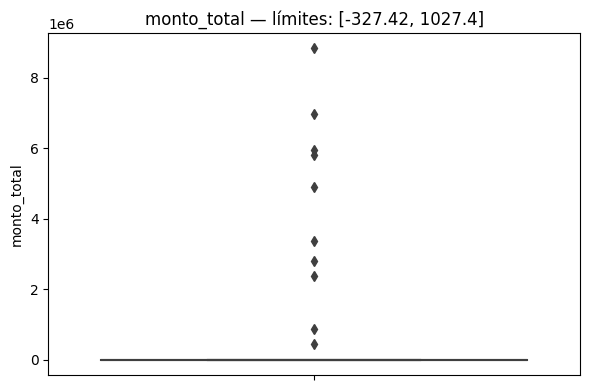

,id_pedido,id_usuario,fecha,pais,dispositivo,canal,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3121,order_3521,user_5812,2025-02-03,mexico,mobile,paid_search,laptop-gaming-16gb,electronica,10000.0,43.14,0.0,431400.0
3122,order_3522,user_3575,2025-03-29,argentina,desktop,social,laptop-gaming-16gb,electronica,10000.0,280.55,0.0,2805500.0
3186,order_3586,user_3380,2025-02-03,mexico,mobile,paid_search,laptop-gaming-16gb,electronica,10000.0,490.35,0.0,4903500.0
3243,order_3643,user_4440,2025-01-07,colombia,desktop,social,laptop-gaming-16gb,electronica,10000.0,238.15,0.0,2381500.0
3256,order_3656,user_884,2025-01-01,argentina,mobile,organic,laptop-gaming-16gb,electronica,20000.0,297.66,0.0,5953200.0
3268,order_3668,user_7270,2025-06-24,mexico,mobile,paid_search,laptop-gaming-16gb,electronica,20000.0,348.31,0.0,6966200.0
3289,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,laptop-gaming-16gb,electronica,10000.0,87.69,0.0,876900.0
3322,order_3722,user_4723,2025-05-09,argentina,mobile,paid_search,laptop-gaming-16gb,electronica,20000.0,442.01,0.0,8840200.0
3326,order_3726,user_2536,2025-02-12,colombia,desktop,social,laptop-gaming-16gb,electronica,20000.0,290.85,0.0,5817000.0
3348,order_3748,user_7096,2025-02-23,mexico,desktop,organic,laptop-gaming-16gb,electronica,10000.0,336.93,0.0,3369300.0


In [ ]:
detectar_outliers(orders, 'monto_total')

---
**📦 Export**: Once the cleaning is finished, I export the datasets to use them in the final stage of the project.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Step 2: Analyze Whether the Business Is Profitable

### 2.1 Core KPI Calculation

**🎯 My objective:** Calculate the key business indicators to evaluate revenue, costs, and profitability.

I use the 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Part 1: Business Profitability**
- What is total revenue?
- What is the total cost?
- How much has been invested in marketing?
- Is the business profitable? (calculate profit)  

---

**📈 Part 2: Sales Behavior**
- What is the average ticket per order?
- What is the average quantity of products per order?
- What is the best-selling product?
- How much has been spent on marketing by channel?

From cleaning to KPIs
With the three datasets already cleaned in Step 1, I move on to preparing them so I can join them and work with the information relevant to calculating the business KPIs. First, I review the available columns in each dataset to identify the correct join keys (`nombre_producto`, `pais`, `canal`).

In [ ]:
print("Columnas en orders:", orders.columns.tolist())
print("Columnas en catalog:", catalog.columns.tolist())
print("Columnas en marketing:", marketing.columns.tolist())

Columnas en orders: ['id_pedido', 'id_usuario', 'fecha', 'pais', 'dispositivo', 'canal', 'nombre_producto', 'categoria_producto', 'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']
Columnas en catalog: ['nombre_producto', 'categoria_producto', 'costo_unitario', 'proveedor']
Columnas en marketing: ['fecha', 'pais', 'id_campaña', 'canal', 'gasto']


💡 Note: I join `orders` with `catalog` to bring each product's unit cost down to the order level — information I need to calculate total cost and, later on, profit.

In [ ]:
# Se unen tablas de orders y catalog para obtener el costo de cada producto
ventas = orders.merge(catalog[['nombre_producto','costo_unitario','proveedor']],
    on='nombre_producto',
    how='left'
    )

In [ ]:
# Se crea una columna con el costo total por cada orden
ventas['costo_total'] = ventas['cantidad'] * ventas['costo_unitario']

In [ ]:
# Se revisan los datos
ventas.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24600 entries, 0 to 24599
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24600 non-null  object        
 1   id_usuario          24600 non-null  object        
 2   fecha               24600 non-null  datetime64[ns]
 3   pais                24600 non-null  object        
 4   dispositivo         24600 non-null  object        
 5   canal               24600 non-null  object        
 6   nombre_producto     24600 non-null  object        
 7   categoria_producto  24600 non-null  object        
 8   cantidad            24600 non-null  float64       
 9   precio_unitario     24600 non-null  float64       
 10  monto_descuento     24600 non-null  float64       
 11  monto_total         24600 non-null  float64       
 12  costo_unitario      24600 non-null  float64       
 13  proveedor           24600 non-null  object    

In [ ]:
# Se visualiza la tabla
ventas.head()

,id_pedido,id_usuario,fecha,pais,dispositivo,canal,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,costo_unitario,proveedor,costo_total
0,order_0,user_6993,2025-05-22,argentina,desktop,organic,jacket-winter-m,moda,2.0,332.69,0.0,665.37,189.31,mcmillan-rhodes,378.62
1,order_1,user_1329,2025-06-15,mexico,desktop,paid_search,tablet-standard-64gb,electronica,1.0,176.86,5.0,171.86,25.21,bowers llc,25.21
2,order_2,user_3194,2025-05-02,argentina,desktop,social,blender-xl-red,hogar,2.0,102.99,10.0,195.99,176.64,long-reid,353.28
3,order_3,user_4510,2025-06-09,colombia,mobile,social,tablet-standard-64gb,electronica,1.0,257.87,15.0,242.87,25.21,bowers llc,25.21
4,order_4,user_5044,2025-03-30,argentina,desktop,paid_search,blender-xl-red,hogar,1.0,336.28,0.0,336.28,176.64,long-reid,176.64


💡 Note: to cross-reference sales with marketing investment without duplicating values, I first aggregate the data at the country and channel level. Joining directly at the individual order level would incorrectly multiply the marketing spend, since it's reported by country/channel, not by order.

In [ ]:
# Se agrupa por pais y canal par luego unir con gasto en marketing sin duplicar valores
resumen_ventas = ventas.groupby(['pais', 'canal'], as_index=False)['monto_total', 'costo_total'].sum()
# Se observa toda la tabla
resumen_ventas

,pais,canal,monto_total,costo_total
0,argentina,organic,7004737.98,6020522.88
1,argentina,paid_search,9892793.38,6023863.72
2,argentina,social,3821525.73,3225582.57
3,colombia,organic,1048655.96,437539.08
4,colombia,paid_search,1039903.98,398947.93
5,colombia,social,9276809.76,8853776.16
6,mexico,organic,4417055.49,3226530.41
7,mexico,paid_search,14253063.43,14447845.91
8,mexico,social,1081829.43,444070.14


In [ ]:
# Se agrupa por pais y canal par luego unir con gasto en marketing sin duplicar valores
resumen_marketing = marketing.groupby(['pais', 'canal'], as_index=False)['gasto'].sum()
# Se observa toda la tabla
resumen_marketing

,pais,canal,gasto
0,argentina,organic,327525.21
1,argentina,paid_search,295394.63
2,argentina,social,324774.76
3,colombia,organic,328055.85
4,colombia,paid_search,297230.13
5,colombia,social,310367.44
6,mexico,organic,323731.38
7,mexico,paid_search,326339.00
8,mexico,social,338425.13


I join `resumen_ventas` and `resumen_marketing` using `how='left'`, to keep every country/channel combination that had sales, even if for some reason there's no marketing spend recorded for one of them.

In [ ]:
# Se crea una tabla final uniendo la anterior con marketing, agrupando por pais y canal
ventas_marketing = pd.merge(resumen_ventas, resumen_marketing, on=['pais', 'canal'], how='left')

In [ ]:
# Se crea una columna con el profit por agrupacion
ventas_marketing['profit'] = (ventas_marketing['monto_total'] - ventas_marketing['costo_total'] - ventas_marketing['gasto'])
# Se observan los datos
ventas_marketing

,pais,canal,monto_total,costo_total,gasto,profit
0,argentina,organic,7004737.98,6020522.88,327525.21,656689.89
1,argentina,paid_search,9892793.38,6023863.72,295394.63,3573535.03
2,argentina,social,3821525.73,3225582.57,324774.76,271168.40
3,colombia,organic,1048655.96,437539.08,328055.85,283061.03
4,colombia,paid_search,1039903.98,398947.93,297230.13,343725.92
5,colombia,social,9276809.76,8853776.16,310367.44,112666.16
6,mexico,organic,4417055.49,3226530.41,323731.38,866793.70
7,mexico,paid_search,14253063.43,14447845.91,326339.00,-521121.48
8,mexico,social,1081829.43,444070.14,338425.13,299334.16


💡 Note: `rentabilidad_total` centralizes the calculation of the global KPIs (revenue, cost, marketing spend, profit, and margin), so I don't have to repeat these operations every time I need to check the business's overall performance.

In [ ]:
# Hallamos rentabilidad y KPis globales
def rentabilidad_total(df):
    revenue_total = df['monto_total'].sum()
    costo_total = df['costo_total'].sum()
    marketing_total = df['gasto'].sum()
    profit = df['profit'].sum()
    margen_pct = calcular_pct(profit, revenue_total)

    print(f'Revenue total: {revenue_total:,.2f}')
    print(f'Costo total: {costo_total:,.2f}')
    print(f'Inversión en marketing: {marketing_total:,.2f}')
    print(f'Profit: {profit:,.2f}')
    print(f'Margen: {margen_pct}%')

In [ ]:
rentabilidad_total(ventas_marketing)

Revenue total: 51,836,375.14
Costo total: 43,078,678.80
Inversión en marketing: 2,871,843.53
Profit: 5,885,852.81
Margen: 11.35%


💡 Note: beyond profitability, I calculate purchase behavior (average ticket, average quantity of products per order, and best-selling products, both by units and by revenue). These metrics complement profitability by showing not just how much the business bills, but how users actually buy.

In [ ]:
# Calcula el ticket promedio, la cantidad promedio y el top de productos por cantidad e ingresos.
def resumen_comportamiento(df):
    # Agrupación por id_pedido
    resumen = df.groupby('id_pedido').agg(
        monto_total=('monto_total', 'sum'),
        cantidad=('cantidad', 'sum')
        )

    # Se calculan metricas de comportamiento
    ticket_promedio = resumen['monto_total'].mean()
    cantidad_promedio = resumen['cantidad'].mean()
    top_unidades = df.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)
    top_revenue = df.groupby('nombre_producto')['monto_total'].sum().sort_values(ascending=False)

    # Retornamos valores
    print('Ticket Promedio por Orden:' , ticket_promedio)
    print('\nCantidad Promedio por Orden:', cantidad_promedio)
    print('\nTop productos por unidades vendidas:')
    print('\n', top_unidades)
    print('\nTop productos por ingreso generado:')
    print('\n', top_revenue)

In [ ]:
resumen_comportamiento(ventas)

Ticket Promedio por Orden: 2107.1697211382116

Cantidad Promedio por Orden: 7.195650406504065

Top productos por unidades vendidas:

 nombre_producto
laptop-gaming-16gb      144160.0
vacuum-pro-black          6203.0
jacket-winter-m           6185.0
blender-xl-red            6184.0
sneakers-urban-42         6085.0
tablet-standard-64gb      4108.0
phone-pro-128gb           4088.0
Name: cantidad, dtype: float64

Top productos por ingreso generado:

 nombre_producto
laptop-gaming-16gb      43420726.73
vacuum-pro-black         1602954.86
jacket-winter-m          1588706.38
blender-xl-red           1587286.76
sneakers-urban-42        1542350.52
tablet-standard-64gb     1050399.57
phone-pro-128gb          1043950.32
Name: monto_total, dtype: float64


Finally, I calculate total marketing spend grouped by channel, as an additional input for the behavior analysis and for the Step 6 dashboard.

In [ ]:
# gasto en markeitng por canal
gasto_canal = marketing.groupby('canal')['gasto'].sum()
gasto_canal

canal
organic        979312.44
paid_search    918963.76
social         973567.33
Name: gasto, dtype: float64

---

## 🔹 Step 3: Understand Where Users Drop Off (Conversion Funnel)

**🎯 My objective:** Analyze user behavior to identify at which stage of the process they drop off.


⚙️**Database connection**:  
I run the configuration line to connect to the database and run SQL queries on the **events** table.

---

**📊 Part 1: Building the Funnel**
- How many users reach each stage of the funnel?  
- I calculate the number of unique users per `nombre_evento`  
- I order the events according to the user flow  

---

**📉 Part 2: Conversion Analysis**
- I calculate the conversion rate between each step of the funnel  
- I identify at which stage the largest number of users drops off  
- What is the final conversion rate?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

I apply the same initial diagnostic to `events` that I used on the Python datasets: I query the full table and review its dimensions and data types before transforming it.

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# Se obrseva tamaño del dataset y tipos de datos.
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   id_usuario          120000 non-null  object
 1   id_sesion           120000 non-null  object
 2   nombre_evento       120000 non-null  object
 3   timestamp_evento    120000 non-null  object
 4   pais                120000 non-null  object
 5   dispositivo         120000 non-null  object
 6   fuente_referencia   120000 non-null  object
 7   categoria_producto  120000 non-null  object
dtypes: object(8)
memory usage: 7.3+ MB


💡 Note: I rename the columns `fuente_referencia` → `canal` and `timestamp_evento` → `fecha` to keep consistent naming with the rest of the project.

In [ ]:
# se convierte la fecha al formato adecuado y se renombran columnas para congruencia con el resto del analisis
events['timestamp_evento'] = pd.to_datetime(events['timestamp_evento'])
events.rename(columns={'fuente_referencia':'canal', 'timestamp_evento': 'fecha'}, inplace=True)

In [ ]:
# se verifican los cambios
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id_usuario          120000 non-null  object        
 1   id_sesion           120000 non-null  object        
 2   nombre_evento       120000 non-null  object        
 3   fecha               120000 non-null  datetime64[ns]
 4   pais                120000 non-null  object        
 5   dispositivo         120000 non-null  object        
 6   canal               120000 non-null  object        
 7   categoria_producto  120000 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 7.3+ MB


Before building the funnel, I need to confirm the exact event names recorded in `nombre_evento`, since these values are used as-is inside the `WHERE` conditions of the SQL queries that build each funnel stage.

In [ ]:
# Se crea query  para observar eventos unicos y cantidades de usuarios
query_eventos_unicos = '''
SELECT DISTINCT nombre_evento
FROM events;
'''
eventos_unicos = pd.read_sql(query_eventos_unicos, con=engine)
eventos_unicos

,nombre_evento
0,add_payment_info
1,first_visit
2,begin_checkout
3,add_to_cart
4,select_item
5,purchase


💡 Building the funnel: I prioritize the analysis in SQL using CTEs (`WITH`) instead of Python; pandas is used only to display the already-calculated results. I first create a subtable (CTE) for each key event in the user's journey, from first visit to purchase, identifying the unique users who reached each stage. I also organize them logically according to the organic path a customer follows through the site's interface.

In [ ]:
#  se crean subtablas filtradas por cada evento
cte_eventos = '''
WITH
cte_first_visit AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'first_visit'
),
cte_select_item AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'
),
cte_add_to_cart AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'
),
cte_begin_checkout AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'
),
cte_add_payment_info AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'
),
cte_purchase AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase'
)
'''

💡 Note: from these subtables, I get the totals of users who reached each stage of the funnel.

In [ ]:
# PARTE 1: Totales del funnel

# se muestran totales de las subtablas de cada evento

query_totals =  cte_eventos + '''
SELECT
    (SELECT COUNT(*) FROM cte_first_visit) AS first_visit_usuarios,
    (SELECT COUNT(*) FROM cte_select_item) AS select_item_usuarios,
    (SELECT COUNT(*) FROM cte_add_to_cart) AS add_to_cart_usuarios,
    (SELECT COUNT(*) FROM cte_begin_checkout) AS begin_checkout_usuarios,
    (SELECT COUNT(*) FROM cte_add_payment_info) AS add_payment_info_usuarios,
    (SELECT COUNT(*) FROM cte_purchase) AS purchase_usuarios;
'''
totals = pd.read_sql(query_totals, con=engine)
totals.T

,0
first_visit_usuarios,7796
select_item_usuarios,7582
add_to_cart_usuarios,7634
begin_checkout_usuarios,7208
add_payment_info_usuarios,6250
purchase_usuarios,6240


💡 Note: here I notice that, relative to the sequential path where I'd expect each stage to show a drop in users compared to the previous one, `select_item` and `add_to_cart` swap order — `add_to_cart` actually has more users than `select_item`. Logically, I'd expect a customer to select a product before adding it to the cart. In this case, this difference may indicate there isn't a single path for adding a product. For example, from the home page a user might be able to add a product directly without selecting it or opening its description page first. If that's the case, it makes sense for `add_to_cart` to have more users than `select_item`. So I don't see a need for a deeper analysis of these two stages.

💡 Note: next, I calculate the cumulative conversion rate relative to the first event (`first_visit`) — that is, what percentage of users who reached the platform actually make it to each following stage.

In [ ]:
# PARTE 2: Conversiones
# Se crean subtablas con las conversiones entre cada paso del funnel
query_conversion = cte_eventos + '''
SELECT
    -- Drop off select_item
    ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_select_item))
        AS dropoff_select_item_count,
    ROUND(
        ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_select_item))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS dropoff_select_item_pct,
    ROUND(
        (SELECT COUNT(*) FROM cte_select_item)::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS conversion_select_item_pct,  -- tambien se puede expresar como (100 - dropoff_select_item_pct)

    -- Drop off add_to_cart
    ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_add_to_cart))
        AS dropoff_add_to_cart_count,
    ROUND(
        ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_add_to_cart))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS dropoff_add_to_cart_pct,
    ROUND(
        (SELECT COUNT(*) FROM cte_add_to_cart)::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS conversion_add_to_cart_pct,

    -- Drop off begin_checkout
    ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_begin_checkout))
        AS dropoff_begin_checkout_count,
    ROUND(
        ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_begin_checkout))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS dropoff_begin_checkout_pct,
    ROUND(
        (SELECT COUNT(*) FROM cte_begin_checkout)::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS conversion_begin_checkout_pct,

    -- Drop off add_payment_info
    ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_add_payment_info))
        AS dropoff_add_payment_info_count,
    ROUND(
        ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_add_payment_info))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS dropoff_add_payment_info_pct,
    ROUND(
        (SELECT COUNT(*) FROM cte_add_payment_info)::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS conversion_add_payment_info_pct,

    -- Drop off purchase
    ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_purchase))
        AS dropoff_purchase_count,
    ROUND(
        ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_purchase))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS dropoff_purchase_pct,
    ROUND(
        (SELECT COUNT(*) FROM cte_purchase)::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS conversion_purchase_pct;
'''
conversion = pd.read_sql(query_conversion, con=engine)
conversion.T

,0
dropoff_select_item_count,214.00
dropoff_select_item_pct,2.74
conversion_select_item_pct,97.26
dropoff_add_to_cart_count,162.00
dropoff_add_to_cart_pct,2.08
conversion_add_to_cart_pct,97.92
dropoff_begin_checkout_count,588.00
dropoff_begin_checkout_pct,7.54
conversion_begin_checkout_pct,92.46
dropoff_add_payment_info_count,1546.00


💡 Note: finally, I calculate user drop-off between each pair of consecutive stages (not just relative to the start of the funnel), which lets me pinpoint exactly which specific step concentrates the biggest user leak.

In [ ]:
# se crean subtablas con las peridas entre cada paso del funnel
query_perdidas = cte_eventos + '''
SELECT
    -- first_visit --> select_item
    ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_select_item))
        AS perdida_after_first_visit,
    ROUND(
        ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_select_item))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0), 2
    ) AS perdida_after_first_visit_pct,

    -- select_item --> add_to_cart
    ((SELECT COUNT(*) FROM cte_select_item) - (SELECT COUNT(*) FROM cte_add_to_cart))
        AS perdida_after_select_item,
    ROUND(
        ((SELECT COUNT(*) FROM cte_select_item) - (SELECT COUNT(*) FROM cte_add_to_cart))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_select_item), 0), 2
    ) AS perdida_after_select_item_pct,

    -- add_to_cart --> begin_checkout
    ((SELECT COUNT(*) FROM cte_add_to_cart) - (SELECT COUNT(*) FROM cte_begin_checkout))
        AS perdida_after_add_to_cart,
    ROUND(
        ((SELECT COUNT(*) FROM cte_add_to_cart) - (SELECT COUNT(*) FROM cte_begin_checkout))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_add_to_cart), 0), 2
    ) AS perdida_after_add_to_cart_pct,

    -- begin_checkout --> add_payment_info
    ((SELECT COUNT(*) FROM cte_begin_checkout) - (SELECT COUNT(*) FROM cte_add_payment_info))
        AS perdida_after_begin_checkout,
    ROUND(
        ((SELECT COUNT(*) FROM cte_begin_checkout) - (SELECT COUNT(*) FROM cte_add_payment_info))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_begin_checkout), 0), 2
    ) AS perdida_after_begin_checkout_pct,

    -- add_payment_info --> purchase
    ((SELECT COUNT(*) FROM cte_add_payment_info) - (SELECT COUNT(*) FROM cte_purchase))
        AS perdida_after_add_payment_info,
    ROUND(
        ((SELECT COUNT(*) FROM cte_add_payment_info) - (SELECT COUNT(*) FROM cte_purchase))::numeric * 100
        / NULLIF((SELECT COUNT(*) FROM cte_add_payment_info), 0), 2
    ) AS perdida_after_add_payment_info_pct;
'''
perdidas = pd.read_sql(query_perdidas, con=engine)
perdidas.T

,0
perdida_after_first_visit,214.00
perdida_after_first_visit_pct,2.74
perdida_after_select_item,-52.00
perdida_after_select_item_pct,-0.69
perdida_after_add_to_cart,426.00
perdida_after_add_to_cart_pct,5.58
perdida_after_begin_checkout,958.00
perdida_after_begin_checkout_pct,13.29
perdida_after_add_payment_info,10.00
perdida_after_add_payment_info_pct,0.16


---

Funnel findings. Of the 7,796 users who reach the platform (`first_visit`), 6,240 complete a purchase, a global conversion rate of 80.04%. Reviewing the drop-off between each pair of consecutive stages (not just the cumulative drop from the start), the biggest leak sits between `begin_checkout` and `add_payment_info`: I lose 958 users, equivalent to 13.29% of those who reached `begin_checkout` — the largest relative drop in the entire funnel, and the step with the greatest potential for improvement (for example, by simplifying the payment form and/or expanding the available payment methods).

## 🔹 Step 4: Evaluate Whether Users Come Back (Cohort Retention)

**🎯 My objective:** Analyze user retention to understand whether they return after signing up.

**Tables**

- `users`
- `user_activity`

---
1. I identify each user's cohort based on their **registration month**.


2. I calculate weekly retention: how many users **stay active** each week since registering.
   - `retenido_w1`: users active in week 1  
   - `retenido_w2`: users active in week 2  
   - `retenido_w3`: users active in week 3  


3. I calculate the retention percentage for each week, dividing retained users by the cohort's initial customers:  
   - `semana_1`: percentage of users retained in week 1  
   - `semana_2`: percentage of users retained in week 2  
   - `semana_3`: percentage of users retained in week 3  

I check that the date column is in the correct format (`DATE`).  
I perform the conversion using: `CAST(fecha_registro AS DATE)`

💡 Note: I query the `users` and `user_activity` tables, needed to build the user cohorts and measure their activity after registration. I also review the data types of both tables, to confirm that `fecha_registro` can be correctly converted to a date inside the SQL query (`CAST(... AS DATE)`) when building the cohorts.

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# se observan tipos de dato y cantidad de registros de la tabla users
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_usuario      8000 non-null   object
 1   fecha_registro  8000 non-null   object
 2   país            8000 non-null   object
 3   dispositivo     8000 non-null   object
 4   tipo_plan       8000 non-null   object
dtypes: object(5)
memory usage: 312.6+ KB


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# se observan tipos de dato y cantidad de registros de la tabla user_activity
user_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id_usuario             32000 non-null  object
 1   fecha_actividad        32000 non-null  object
 2   dias_despues_registro  32000 non-null  int64 
 3   activo                 32000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 1000.1+ KB


💡 Building the cohorts: I group each user by the week of their registration date (`DATE_TRUNC('week', ...)`) and cross this information with their subsequent activity (`user_activity`), as the basis for later calculating what percentage of each cohort stays active in the following weeks.

In [ ]:
# Se crean los cohortes y se muestran sus datos
cte_cohortes = '''
WITH cohortes AS (
    SELECT
        u.id_usuario AS usuario,
        DATE_TRUNC('week', MIN(CAST(u.fecha_registro AS DATE))) AS cohorte_semana,
        ua.dias_despues_registro,
        ua.activo
    FROM users u
    LEFT JOIN user_activity ua ON u.id_usuario = ua.id_usuario
    GROUP BY u.id_usuario, ua.dias_despues_registro, ua.activo
)
'''
query_cohorte_preview = cte_cohortes + '''
SELECT * FROM cohortes;
'''

cohorte = pd.read_sql(query_cohorte_preview, con=engine)
cohorte.head()

,usuario,cohorte_semana,dias_despues_registro,activo
0,user_4385,2025-05-12 00:00:00+00:00,7,1
1,user_351,2024-12-30 00:00:00+00:00,28,0
2,user_1680,2025-01-13 00:00:00+00:00,14,0
3,user_3969,2025-01-13 00:00:00+00:00,7,0
4,user_6286,2025-01-13 00:00:00+00:00,21,0


💡 Note: with the cohort base already built, I calculate the retention percentage for weeks 1, 2, and 3 relative to each cohort's total initial users, which lets me compare retention performance across different registration weeks.

In [ ]:
# Retención por cohortes
# Se crea y muestra la tabla de cohortes y retencion por semana en porcentaje
query_cohort_retention_final = cte_cohortes + '''
, retencion AS (
    SELECT
        cohorte_semana,
        COUNT(DISTINCT usuario) AS clientes_iniciales,
        COUNT(DISTINCT CASE WHEN dias_despues_registro >= 1 AND activo = 1 THEN usuario END) AS retencion_w1,
        COUNT(DISTINCT CASE WHEN dias_despues_registro >= 8 AND activo = 1 THEN usuario END) AS retencion_w2,
        COUNT(DISTINCT CASE WHEN dias_despues_registro >= 15 AND activo = 1 THEN usuario END) AS retencion_w3
    FROM cohortes
    GROUP BY cohorte_semana
)
SELECT
    TO_CHAR(cohorte_semana, 'IYYY-IW') AS cohorte,
    clientes_iniciales,
    ROUND(retencion_w1::numeric * 100 / NULLIF(clientes_iniciales, 0), 2) AS semana_1,
    ROUND(retencion_w2::numeric * 100 / NULLIF(clientes_iniciales, 0), 2) AS semana_2,
    ROUND(retencion_w3::numeric * 100 / NULLIF(clientes_iniciales, 0), 2) AS semana_3
FROM retencion
ORDER BY cohorte_semana;
'''

cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final


,cohorte,clientes_iniciales,semana_1,semana_2,semana_3
0,2025-01,236,85.17,77.97,63.98
1,2025-02,351,84.33,77.49,64.10
2,2025-03,362,84.25,75.41,62.15
3,2025-04,394,84.01,74.87,61.93
4,2025-05,373,87.40,81.23,65.42
5,2025-06,405,86.67,81.98,68.89
6,2025-07,364,87.36,81.32,65.11
7,2025-08,338,87.28,77.22,60.36
8,2025-09,353,87.82,78.75,64.02
9,2025-10,363,87.33,79.89,62.81


💡 Note: `analizar_cohortes` automatically identifies, for each retention week, which cohort performed best and worst, making the table much faster to read without having to check it manually row by row.

In [ ]:
# Analiza y devulve el mejor y peor cohorte por semana
def analizar_cohortes(cohorte_final):
  semanas = ["semana_1", "semana_2", "semana_3"]
  resultados = {}

  for semana in semanas:
    # Ordenamos el DataFrame de mayor a menor retención para la semana actual
    cohortes_ordenadas = cohorte_final.sort_values(semana, ascending=False)

    mejor = cohortes_ordenadas.iloc[0]
    peor = cohortes_ordenadas.iloc[-1]

    resultados[semana] = {
        "mejor_cohorte": mejor["cohorte"],
        "mejor_valor": mejor[semana],
        "peor_cohorte": peor["cohorte"],
        "peor_valor": peor[semana],
    }
    print(f" Resultados para {semana} ")
    print(
        f"Mejor retención: cohorte {mejor['cohorte']}, con"
        f" {mejor[semana]}%."
    )
    print(
        f"Peor retención:  cohorte {peor['cohorte']}, con {peor[semana]}%.\n"
    )

analizar_cohortes(cohorte_final)

 Resultados para semana_1 
Mejor retención: cohorte 2025-15, con 88.92%.
Peor retención:  cohorte 2025-18, con 83.64%.

 Resultados para semana_2 
Mejor retención: cohorte 2025-06, con 81.98%.
Peor retención:  cohorte 2025-18, con 73.09%.

 Resultados para semana_3 
Mejor retención: cohorte 2025-06, con 68.89%.
Peor retención:  cohorte 2025-18, con 58.58%.



---

Retention findings: retention drops consistently over time: on average, around 86% of users remain active in week 1, ~78% in week 2, and ~64% in week 3. The February 2025 cohort (2025-06) has the best retention in weeks 2 and 3 (81.98% and 68.89%), while cohort 2025-18 (late April) has the worst in both weeks (73.09% and 58.58%) — a gap of nearly 10 percentage points that's worth investigating (did something change in user acquisition, in that specific cohort's experience, or could it be related to seasonality during that particular period?).

💡 Note: to make visual comparison across cohorts easier, I build a matrix with cohorts as rows and retention weeks as columns, which serves as the basis for the heatmap. This lets me visually confirm what I already determined through the analysis.

In [ ]:
# se crea una matriz en donde solo se muestren valores numericos y los demas titulos se muestren como indices
matriz_retencion = cohorte_final.set_index('cohorte')[['semana_1', 'semana_2', 'semana_3']]
matriz_retencion

,semana_1,semana_2,semana_3
cohorte,,,
2025-01,85.17,77.97,63.98
2025-02,84.33,77.49,64.10
2025-03,84.25,75.41,62.15
2025-04,84.01,74.87,61.93
2025-05,87.40,81.23,65.42
2025-06,86.67,81.98,68.89
2025-07,87.36,81.32,65.11
2025-08,87.28,77.22,60.36
2025-09,87.82,78.75,64.02


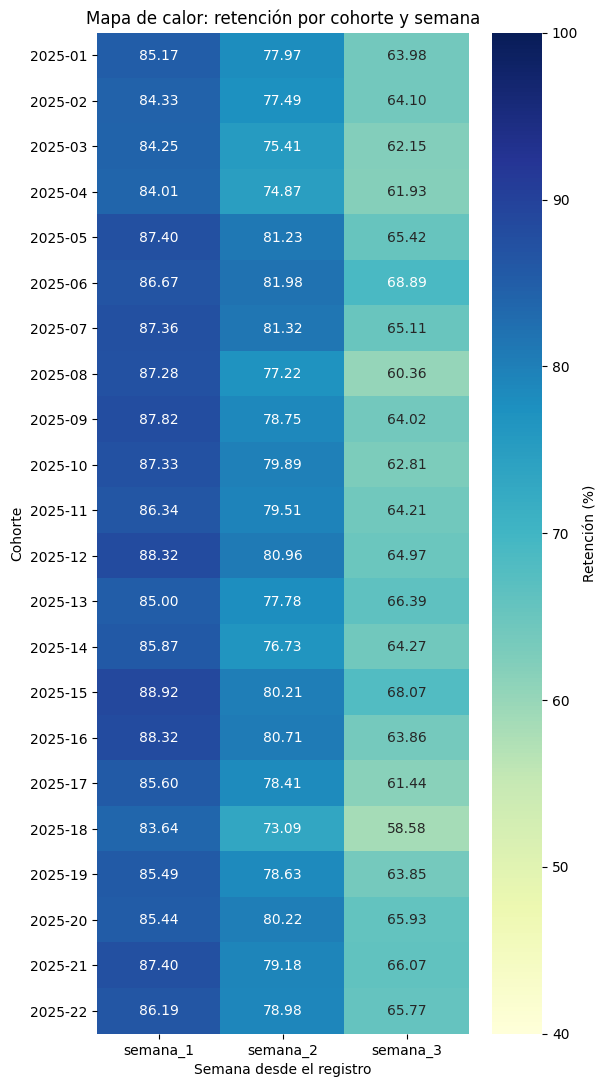

In [ ]:
# se observan los cohortes con mejor y pero retencon mediante un mapa de calor
plt.figure(figsize=(6, len(matriz_retencion) * 0.5 + 2))
sns.heatmap(
    matriz_retencion,
    annot=True,
    fmt= '.2f',
    cmap= 'YlGnBu',
    vmin= 40,
    vmax= 100,
    cbar_kws={'label': 'Retención (%)'}
)
plt.title('Mapa de calor: retención por cohorte y semana')
plt.xlabel('Semana desde el registro')
plt.ylabel('Cohorte')
plt.show()

## 🔹 Step 5: Validate Whether the Changes Have an Impact (Statistical Test)

🎯 **My objective:** Evaluate whether the checkout UI change impacts the **purchase conversion rate**.

---

1. **I analyze the dataset** `experiment_checkout_ui.csv` to identify the main metric, **conversion**.
   - The **conversion** metric is 1 if the user completed the purchase, 0 if not.    
2. **I state the statistical hypothesis**     
3. **I apply the appropriate statistical test**
4. **I interpret the result**  

---
Statistical hypothesis
   - **H₀ (Null hypothesis):** there is no real difference in conversion rate between control and treatment. Any difference observed in the data is due to chance.
   - **H₁ (Alternative hypothesis):** there is a real difference in conversion rate between control and treatment. The interface change has an effect on whether the user purchases or not.
   
**Statistical test:** Z-test of proportions   
**Significance level (alpha):** 0.05

💡 Note: I load the A/B experiment dataset (`experiment_checkout_ui.csv`), which records whether each user converted or not, based on the checkout variant they were assigned to (control or treatment). I also import the library needed to run the appropriate statistical test. Since it's a binary column, the right choice is the Z-test of proportions.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
experiment.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [ ]:
experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [ ]:
print(experiment['convirtio'].unique())
print(experiment['variante'].value_counts())

[0 1]
tratamiento    5035
control        4965
Name: variante, dtype: int64


💡 Note: I review the unique values of the conversion variable and the distribution of users across variants, and calculate the observed conversion rate in each group, as a step before the statistical test.

In [ ]:
resumen_variantes = experiment.groupby('variante')['convirtio'].agg(
    conversiones='sum',
    usuarios='count'
).reset_index()

resumen_variantes['tasa_conversion_pct'] = round(
    resumen_variantes['conversiones'] / resumen_variantes['usuarios'] * 100, 2
)

resumen_variantes

,variante,conversiones,usuarios,tasa_conversion_pct
0,control,779,4965,15.69
1,tratamiento,820,5035,16.29


💡 Statistical test: since the conversion variable is binary (converted / did not convert), I apply a Z-test of proportions (`proportions_ztest`) to evaluate whether the observed difference between control and treatment is statistically significant or could simply be due to chance. I need to build a 2x2 table containing just 4 values: the successes (conversions) for control and treatment, and their total observations.

In [ ]:
conversiones_control = resumen_variantes.loc[resumen_variantes['variante'] == 'control', 'conversiones'].iloc[0]
usuarios_control = resumen_variantes.loc[resumen_variantes['variante'] == 'control', 'usuarios'].iloc[0]

conversiones_tratamiento = resumen_variantes.loc[resumen_variantes['variante'] == 'tratamiento', 'conversiones'].iloc[0]
usuarios_tratamiento = resumen_variantes.loc[resumen_variantes['variante'] == 'tratamiento', 'usuarios'].iloc[0]

# Número de éxitos (conversiones) por grupo
exitos = [conversiones_control, conversiones_tratamiento]

# Número total de observaciones (usuarios) por grupo
observaciones = [usuarios_control, usuarios_tratamiento]

# Aplicar la prueba
z_stat, p_value = proportions_ztest(exitos, observaciones)

print(f'Estadístico z: {round(z_stat, 4)}')
print(f'Valor p: {round(p_value, 4)}')

Estadístico z: -0.8133
Valor p: 0.4161


💡 Note: with a significance level (alpha) of 0.05, I compare the obtained p-value against this threshold to decide whether to reject the null hypothesis. The result was z = -0.8133 and p = 0.4161 (well above 0.05), so I fail to reject H₀: the difference between the control conversion rate (15.69%) and the treatment conversion rate (16.29%) is not statistically significant and is consistent with random variation. Consequently, there's no evidence that the interface change improved conversion.

In [ ]:
alpha = 0.05

if p_value < alpha:

    print('Se rechaza H0')
    print('Hay evidencia estadística de que la tasa de conversión es diferente entre control y tratamiento.')
else:
    print('No se rechaza H0.')
    print('No hay evidencia suficiente de que la tasa de conversión sea diferente entre control y tratamiento.')

No se rechaza H0.
No hay evidencia suficiente de que la tasa de conversión sea diferente entre control y tratamiento.


EXECUTIVE SUMMARY

1. Overall profitability, with one segment operating at a loss
Context
I analyze profitability across the three countries and three acquisition channels RappiPlus operated in during 2025 (revenue, product cost, and marketing investment).
Finding
The business closes with a profit of +$5.89M (margin of +11.35%) on revenue of $51.8M. However, the Mexico / Paid Search segment operates at a loss (-$521K), while Argentina / Paid Search is the most profitable segment (+$3.57M, 3x Colombia's most profitable segment).
Implication
Mexico's Finance and Marketing teams should audit the cost per acquisition and pricing for the paid_search channel in that country (is it a high product unit cost, elevated marketing spend, or excessive discounts?) and decide whether to pause, renegotiate, or restructure investment in that channel for the next semester.

2. Checkout is the funnel's biggest leak
Context
I analyze the journey of the 7,796 users who visited the platform, from first visit to purchase.
Finding
Global conversion is 80.04%, a solid indicator, but the single biggest drop happens between begin_checkout and add_payment_info: I lose 958 users (-13.29%) in that one step alone — more than double any other funnel transition.
Implication
The Product/UX team should prioritize a review of the payment form (number of fields, ease of completion, available payment methods, load times) and run a usability test with real users before implementation, since this is the single largest bottleneck in the entire purchase journey.

3. Retention drops over time, with one identifiable weak cohort
Context
Weekly retention (weeks 1, 2, and 3 after registration) across 22 cohorts of users registered between January and June 2025.
Finding
Average retention drops from ~86% in week 1 to ~64% in week 3. The week-18 cohort (late April 2025) has the worst retention in weeks 2 and 3 (73.09% and 58.58%), nearly 10 percentage points below the best-performing cohort (week 6, mid-February: 81.98% and 68.89%).
Implication
The Retention team should investigate what specifically changed in week 18 (acquisition channel, an active campaign, product incidents) and, in parallel, document and replicate week 6's retention practices in future acquisition campaigns.

4. The tested checkout change did not improve conversion
Context
An A/B experiment on a new user interface, with 10,000 users split between control (4,965) and treatment (5,035).
Finding
Conversion was 15.69% for control vs. 16.29% for treatment (+0.6 pp), but the Z-test of proportions finds no statistically significant difference (z = -0.81, p = 0.4161), well above α = 0.05.
Implication
The Product team should not ship this UI change to production based on current evidence. I'd recommend discarding this change and exploring a different design hypothesis, weighing whether the cost involved is worth it against the expected conversion gain.

Personal reflection

●	Of the four findings, which would have the biggest revenue impact if solved first: the loss-making segment, checkout, retention, or the experiment?

●	What additional data would I need before making a decision on the Mexico / Paid Search segment?


---

## 🔹 Step 6: Communicate the Results (BI Dashboard)

🎯 **My objective**:  
Build a dashboard that clearly and visually presents the results of the sales, cost and marketing analysis.

I use the clean CSVs from Step 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---


---

## 🚀 Final Delivery

I share access to my Dashboard for review.   

### 📎 Dashboard Google Drive Link

https://drive.google.com/file/d/14FnPaWl0VsW-F8P7kJrNkvzsi2IrRQKT/view?usp=sharing
